# 05. Graph Model Comparison

This notebook trains and compares all graph baselines under the same split and feature setup:

- `GCN`
- `GraphSAGE`
- `GAT`
- `GGNN`

Each model uses its own default hyperparameter preset, but all models share the same dataset split, evaluation protocol, threshold tuning, and reporting metrics.
The default comparison is stricter by keeping `ADD_GRAPH_STATS = False`.


In [1]:
from pathlib import Path
import sys
import time

import pandas as pd

sys.path.append(str(Path.cwd()))

from graph_model_utils import (
    build_graph_dataset,
    find_best_threshold,
    get_model,
    plot_comparison_bars,
    plot_evaluation_dashboard,
    predict_probabilities,
    set_seed,
    train_model,
    evaluate_probabilities,
)


c:\Users\gupta\Music\mlproj\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
FEATURE_GROUP = "eth_twitter_combined_features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
THRESHOLD_OBJECTIVE = "f1"

MODEL_CONFIGS = {
    "gcn": {"hidden_dim": 64, "dropout": 0.2, "learning_rate": 1e-3, "epochs": 100, "patience": 15},
    "graphsage": {"hidden_dim": 64, "dropout": 0.2, "learning_rate": 1e-3, "epochs": 100, "patience": 15},
    "gat": {"hidden_dim": 32, "dropout": 0.3, "learning_rate": 7.5e-4, "epochs": 120, "patience": 18},
    "ggnn": {"hidden_dim": 64, "dropout": 0.2, "learning_rate": 1e-3, "epochs": 100, "patience": 15},
}

set_seed(RANDOM_STATE)


In [3]:
data = build_graph_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(pd.DataFrame([data["graph_summary"]]))
display(data["split_df"])
print("Device:", data["device"])
print("Number of input features:", len(data["feature_cols"]))


,num_nodes,num_edges,num_features,positive_nodes,negative_nodes,has_self_loops_after_build
0,10000,283909,24,1126,8874,True


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Device: cpu
Number of input features: 24


In [4]:
results = []
fitted = {}
histories = {}

for model_name, cfg in MODEL_CONFIGS.items():
    set_seed(RANDOM_STATE)
    model = get_model(
        model_name=model_name,
        in_dim=data["features"].shape[1],
        hidden_dim=cfg["hidden_dim"],
        dropout=cfg["dropout"],
    )

    start = time.perf_counter()
    best_model, history_df = train_model(
        model=model,
        data=data,
        learning_rate=cfg["learning_rate"],
        weight_decay=1e-4,
        epochs=cfg["epochs"],
        patience=cfg["patience"],
        threshold_objective=THRESHOLD_OBJECTIVE,
    )
    elapsed = time.perf_counter() - start

    val_true, val_prob = predict_probabilities(best_model, data, "val_mask")
    threshold = find_best_threshold(val_true, val_prob, objective=THRESHOLD_OBJECTIVE)
    test_true, test_prob = predict_probabilities(best_model, data, "test_mask")
    metrics = evaluate_probabilities(test_true, test_prob, threshold)

    results.append(
        {
            "model": model_name,
            "epochs_ran": int(history_df["epoch"].max()),
            "train_seconds": elapsed,
            **metrics,
        }
    )
    fitted[model_name] = {
        "model": best_model,
        "threshold": threshold,
        "test_true": test_true,
        "test_prob": test_prob,
        "history": history_df,
    }
    histories[model_name] = history_df


In [5]:
results_df = pd.DataFrame(results).sort_values(["PR-AUC", "F1"], ascending=False)
display(results_df)


,model,epochs_ran,train_seconds,Threshold,PR-AUC,ROC-AUC,F1,Precision,Recall,Specificity,...,Brier-Score,Log-Loss,Accuracy,TP,FP,TN,FN,TopK,Precision@K,Recall@K
3,ggnn,100,134.420627,0.800,0.814514,0.963550,0.727794,0.705556,0.751479,0.960180,...,0.075836,0.249528,0.936667,127,53,1278,42,169,0.733728,0.733728
1,graphsage,100,30.609322,0.700,0.738897,0.932413,0.662722,0.662722,0.662722,0.957175,...,0.088888,0.305160,0.924000,112,57,1274,57,169,0.662722,0.662722
0,gcn,39,21.388502,0.525,0.716726,0.916642,0.675900,0.635417,0.721893,0.947408,...,0.215515,0.622525,0.922000,122,70,1261,47,169,0.680473,0.680473
2,gat,120,77.903833,0.550,0.674334,0.892746,0.612500,0.649007,0.579882,0.960180,...,0.152946,0.490744,0.917333,98,53,1278,71,169,0.621302,0.621302


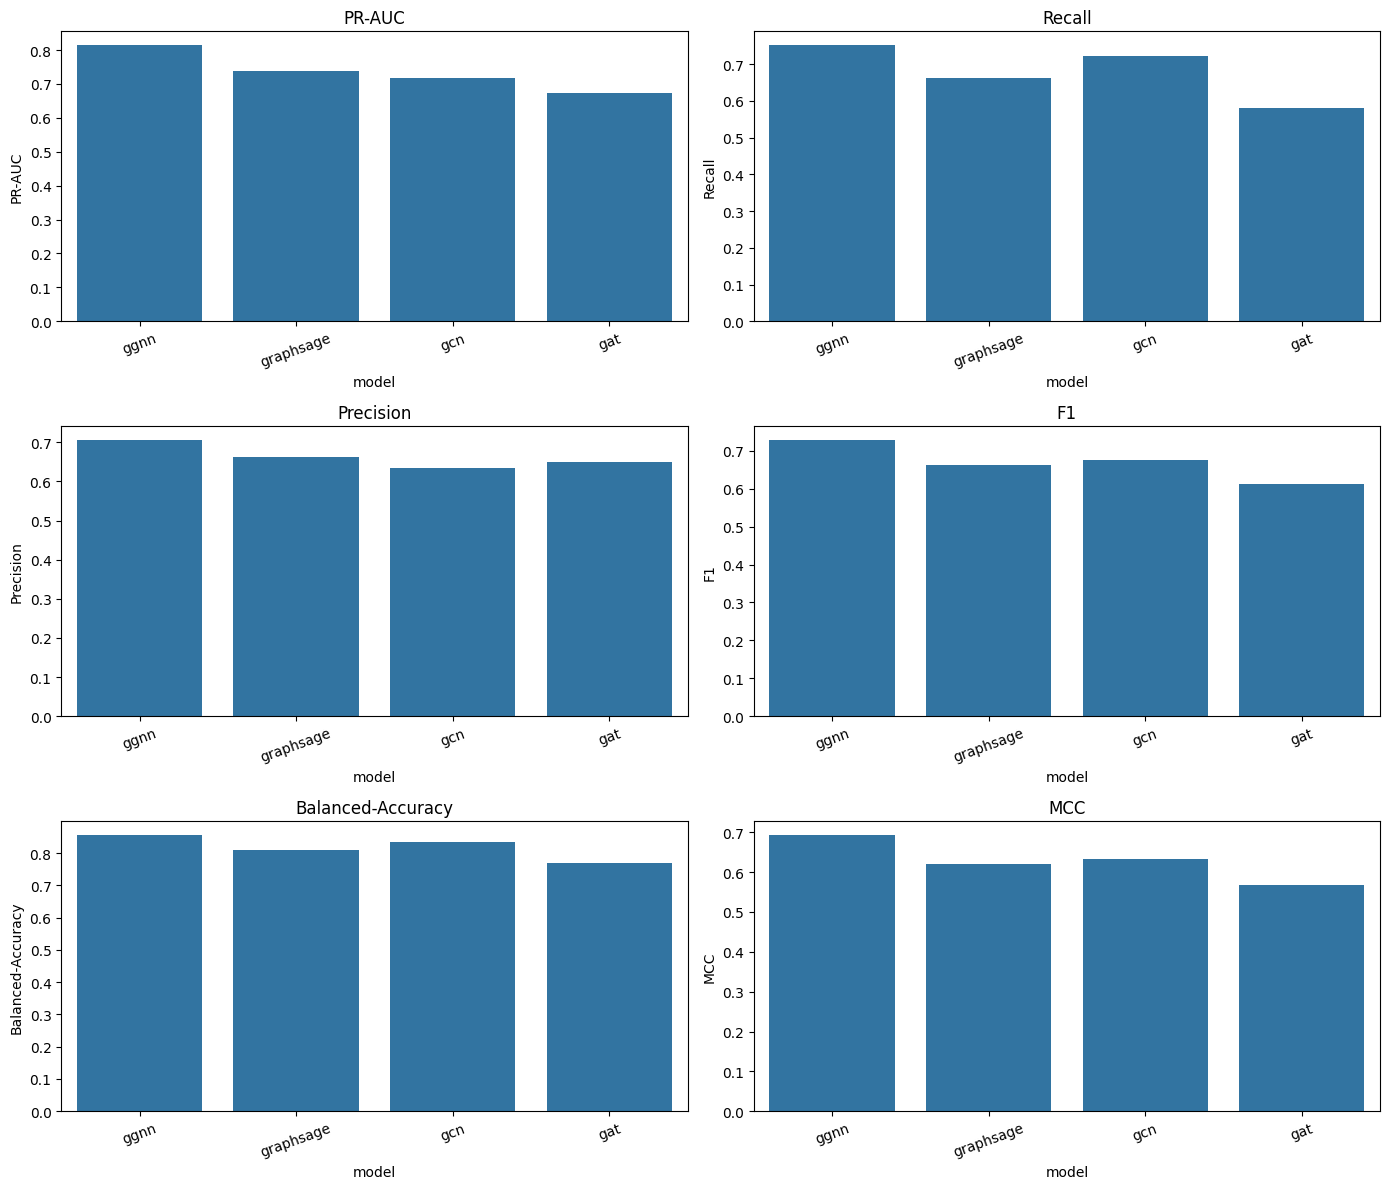

In [6]:
plot_comparison_bars(results_df)


Best graph model: ggnn


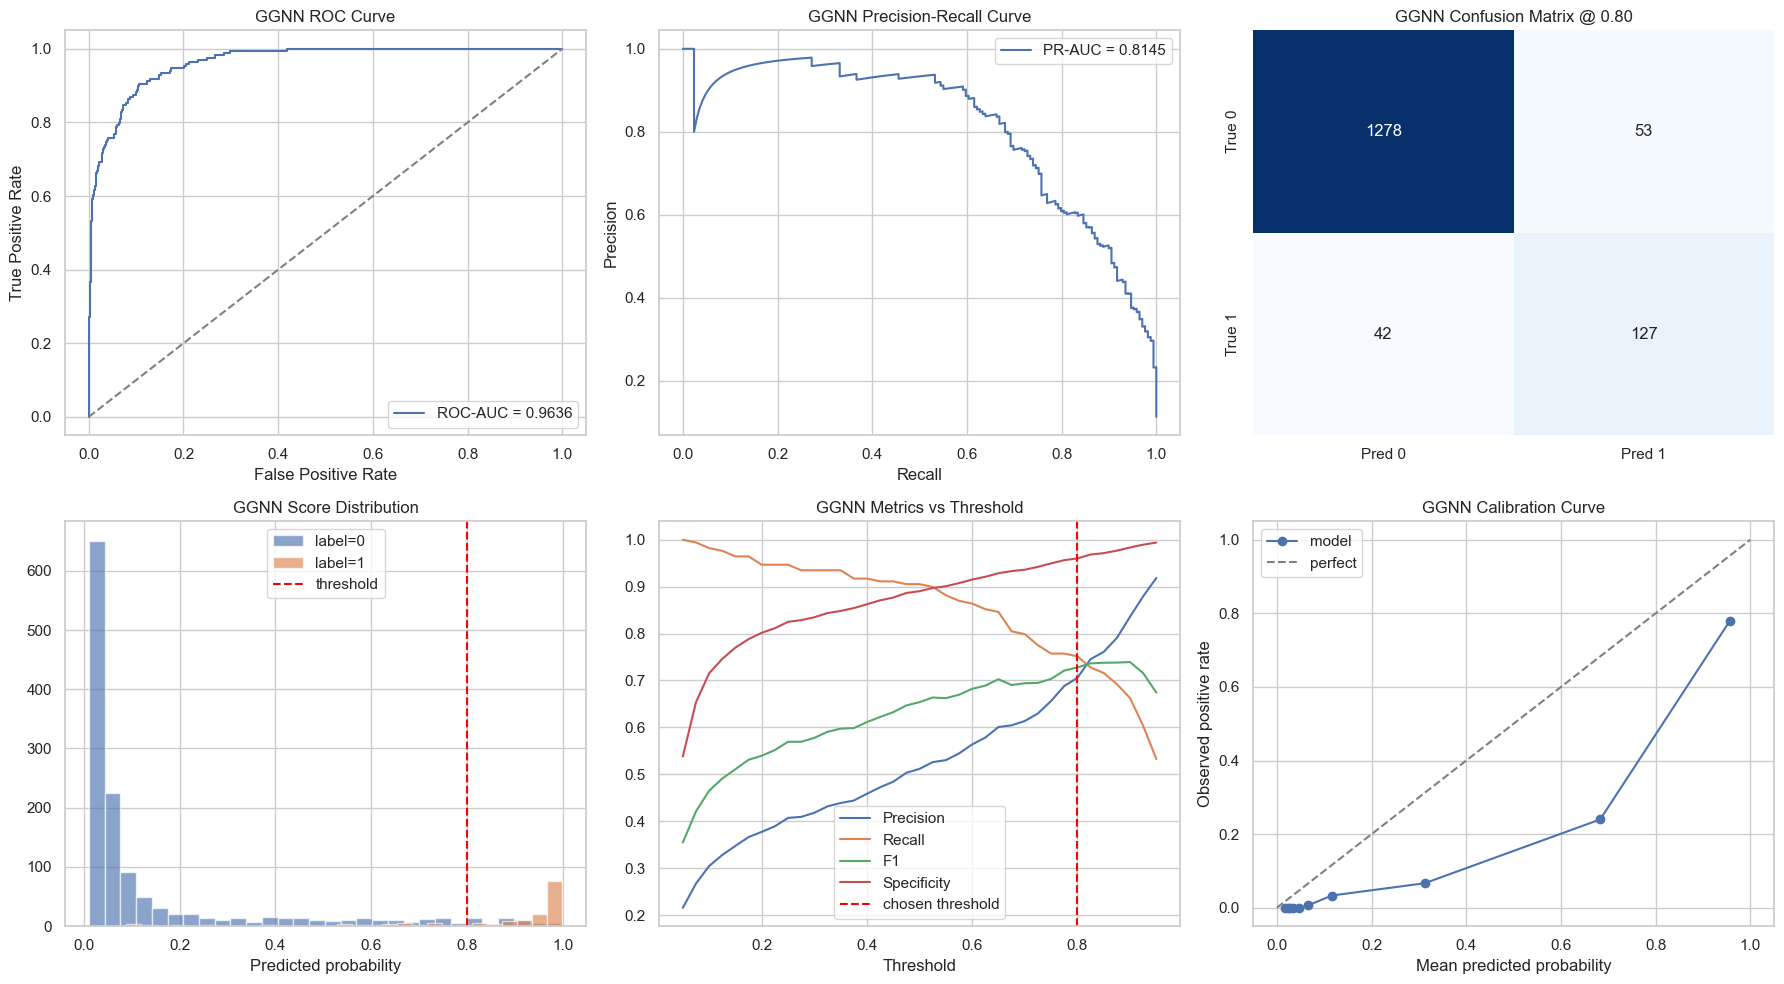

In [7]:
best_model_name = results_df.iloc[0]["model"]
print("Best graph model:", best_model_name)

best_result = fitted[best_model_name]
plot_evaluation_dashboard(
    y_true=best_result["test_true"],
    y_prob=best_result["test_prob"],
    threshold=best_result["threshold"],
    title_prefix=best_model_name.upper(),
)


In [ ]:
summary_cols = [
    "model",
    "PR-AUC",
    "ROC-AUC",
    "F1",
    "Precision",
    "Recall",
    "Specificity",
    "Balanced-Accuracy",
    "MCC",
    "Brier-Score",
    "Accuracy",
    "Precision@K",
    "Recall@K",
    "epochs_ran",
    "train_seconds",
]
results_df[summary_cols]


,model,PR-AUC,ROC-AUC,F1,Precision,Recall,Specificity,Balanced-Accuracy,MCC,Brier-Score,Accuracy,Precision@K,Recall@K,epochs_ran,train_seconds
3,ggnn,0.814514,0.963550,0.727794,0.705556,0.751479,0.960180,0.855830,0.692439,0.075836,0.936667,0.733728,0.733728,100,134.420627
1,graphsage,0.738897,0.932413,0.662722,0.662722,0.662722,0.957175,0.809948,0.619897,0.088888,0.924000,0.662722,0.662722,100,30.609322
0,gcn,0.716726,0.916642,0.675900,0.635417,0.721893,0.947408,0.834651,0.633432,0.215515,0.922000,0.680473,0.680473,39,21.388502
2,gat,0.674334,0.892746,0.612500,0.649007,0.579882,0.960180,0.770031,0.567520,0.152946,0.917333,0.621302,0.621302,120,77.903833


: 

## Notes

This notebook is the main leaderboard for graph models.
It defaults to a stricter feature-only setup by keeping `ADD_GRAPH_STATS = False`.
If you later tune hyperparameters, keep the same split and threshold-selection protocol so the comparison remains valid.
